# 1. Title: Energy, Emissions and Development

### Name: Raul Miranda
### Date: April 2, 2026

## 2. Short Introduction

Energy use is an indicator of technological, economic and social development across nations. Over the past 125 years, the dominant source of energy has been of fossil origin, such as coal, oil and gas, and the primary process to extract energy from fossil resources has been combustion, leading to massive release of CO2 into the atmosphere. Such accumulation has become significant and rapidly growing since 1950 reaching levels that may induce global warming and alter normal earth and atmospheric cycles. Alongside CO2 emission, there has been an increase in methane emission, another potent greenhouse gas. It is unclear whether both emissions, (CO2 and methane) are correlated, as the causes of their generation and release are different. Another interesting fact is that renewable sources of energy are becoming important, and that their use may lead to lower emissions of CO2 relative to fossil sources.

This project seeks to answer basic questions: **is CO2 emission quantitatively correlated with the technological and economic development of nations over the past 30 years? Have different regions of the world developed independent correlations? Is renewable energy use evidenced by a reduction in CO2 production?  Is methane emission following similar trends to CO2?**

### Datasets

**Our World in Data: CO2 and methane emissions, share of emissions from the various sources.** https://github.com/owid/co2-data
**World Bank - Patent applications as measure of technological advancement.** https://data.worldbank.org/indicator/IP.PAT.RESD

### Data limitations. Population of interest. Bias concerns.

A single repository is insufficient to cover the stated scope of this project, thus we resorted to OWID for greenhouse gas emissions data and GDP/capita, and to World Bank for patents. Other approaches to measuring advancement are possible, particularly if social and human factors are included. But to keep the project feasible within a short period, only technological and economic factors are considered. 

The number of patent applications submitted by each country is a possible indicator of intellectual property generation and technological influence. Likewise, the GDP/capita is a reasonable measure of economic development and standard of living. 
A note about renewable energy: rather than pulling that information from another database, we will use CO2 generated per energy unit (present in the OWID datset) as an indirect measure of renewables; the CO2 generation decreases with increasing fraction of renewable/fossil.     

The population of interest is the world; the emissions data has been partially reported by about 250 nations; the patent data is available for 150 countries. A major limitation is that both types of data are more or less complete only for the last 30 years (1990-2022), but are spotty otherwise, particularly for the less developed regions of the world, and for those with restrictive reporting policies. Thus the conclusions from this study may be biased by the lack of data from certain nations.  

## 3. Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the plot themes and style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5),
                     'axes.titlesize': 13, 'axes.labelsize': 11})

## 4. Load the Data

We'll load the 2 sets and merge them by "country" and "year":

1. **OWID CO2 dataset** – CO2 and methane emissions, GDP, methane, CO2 per unit of energy.  
2. **World Bank patent applications** – the resident patent apps by country and year, avail. in wide format, thus reshaped to long format.

"owid-co2-data.csv" was downloaded from https://github.com/owid/co2-data  into the same folder as this notebook.

"wb_patents.csv" was downloaded from https://data.worldbank.org/indicator/IP.PAT.RESD into the same folder.

In [3]:
# load OWID and show its shape and columns (ca. 50K rows and 79 columns)

owid = pd.read_csv("owid-co2-data.csv")
print(f"OWID shape: {owid.shape}")
print("\nColumn names:")
for c in owid.columns:
    print(" ", c)

OWID shape: (50411, 79)

Column names:
  country
  year
  iso_code
  population
  gdp
  cement_co2
  cement_co2_per_capita
  co2
  co2_growth_abs
  co2_growth_prct
  co2_including_luc
  co2_including_luc_growth_abs
  co2_including_luc_growth_prct
  co2_including_luc_per_capita
  co2_including_luc_per_gdp
  co2_including_luc_per_unit_energy
  co2_per_capita
  co2_per_gdp
  co2_per_unit_energy
  coal_co2
  coal_co2_per_capita
  consumption_co2
  consumption_co2_per_capita
  consumption_co2_per_gdp
  cumulative_cement_co2
  cumulative_co2
  cumulative_co2_including_luc
  cumulative_coal_co2
  cumulative_flaring_co2
  cumulative_gas_co2
  cumulative_luc_co2
  cumulative_oil_co2
  cumulative_other_co2
  energy_per_capita
  energy_per_gdp
  flaring_co2
  flaring_co2_per_capita
  gas_co2
  gas_co2_per_capita
  ghg_excluding_lucf_per_capita
  ghg_per_capita
  land_use_change_co2
  land_use_change_co2_per_capita
  methane
  methane_per_capita
  nitrous_oxide
  nitrous_oxide_per_capita
  oil_co2

In [ ]:
# get patents from World Bank -- years are in columns; skip first 4 rows with title info; 
# since it comes in wide format, we must convert the dataset to long format
  
patents_wide = pd.read_csv("wb_patents.csv", skiprows=4)

# Keep country name and year columns only

year_cols = []
for c in patents_wide.columns:    #scan each column name
    if c.strip().isdigit():       #if it is a digit, ie a year
        year_cols.append(c)       #append it to year_cols; it is appended as a string

patents_long = patents_wide[['Country Name'] + year_cols].copy()   #create the patents_long table...still in wide format
patents_long = patents_long.melt(                                  #now melt it into the long format           
    id_vars='Country Name',                                        #with id: country name
    value_vars=year_cols,                                          #
    var_name='year',                                               #var: year
    value_name='patent_applications')                              #value: number of patent appls  

patents_long.rename(columns={'Country Name': 'country'}, inplace=True)
patents_long['year'] = patents_long['year'].astype(int)            #convert year from string to integer
patents_long['patent_applications'] = pd.to_numeric(               #convert non-numeric info to numeric if a number
    patents_long['patent_applications'], errors='coerce')          # or coerce them to NaN if empty

print(f"Patents long shape: {patents_long.shape}")
patents_long.head(3)

Patents long shape: (17556, 3)


,country,year,patent_applications
0,Aruba,1960,NaN
1,Africa Eastern and Southern,1960,NaN
2,Afghanistan,1960,NaN


In [5]:
# merge the owid and patents_long databases
df = owid.merge(patents_long, on=['country', 'year'], how='left')
print(f"Merged shape: {df.shape}")
df.head(3)

Merged shape: (50411, 80)


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share,patent_applications
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Dataset Structure

Each **row** corresponds to a country (or global/regional aggregate) in a specific year.  
The dataset goes from the early 1800s to the mid-2020s for over 250 countries and  regions; however, in later
data wrangling, we'll leave only 30 years and we'll remove all rows without a country code.


In [6]:
print(f"Rows: {df.shape[0]:,}")   # rows
print(f"Columns: {df.shape[1]:,}")   # columns
print(f"\nUnique countries/regions: {df['country'].nunique()}")
print(f"Year range: {df['year'].min()} - {df['year'].max()}")

Rows: 50,411
Columns: 80

Unique countries/regions: 254
Year range: 1750 - 2024


In [7]:
# dictionary of the variables we will use
var_dict = {
    'country':               ('Name of the country',            'Categorical'),
    'year':                  ('Calendar year of observation',              'Quantitative'),
    'iso_code':              ('ISO 3-letter country code',                 'Categorical'),
    'population':            ('Total population',                          'Quantitative'),
    'gdp':                   ('Gross domestic product (constant 2011 USD)','Quantitative'),
    'co2':                   ('Annual CO2 emissions (million tonnes)',      'Quantitative'),
    'methane':               ('Annual methane emissions (MtCO2e)',          'Quantitative'),
    'oil_co2':               ('CO2 from oil combustion (MtCO2)',           'Quantitative'),
    'gas_co2':               ('CO2 from gas combustion (MtCO2)',           'Quantitative'),
    'primary_energy_consumption':('Total primary energy (TWh)',            'Quantitative'),
    'patent_applications':   ('Resident patent filings (WIPO)',            'Quantitative'),
    'co2_per_unit_energy **': ('Renewable energy proxy (kg CO2/kWh)',      'Quantitative'),
}

print(f"{'Variable':<28} {'Definition':<55} {'Type'}")
print("-"*100)
for var, (defn, typ) in var_dict.items():
    print(f"{var:<28} {defn:<55} {typ}")
print("""    ** CO2 emitted per unit of energy consumed (kg CO2/kWh) —
       used as proxy for renewable energy penetration:
       lower values indicate a cleaner, more renewable energy mix""")


Variable                     Definition                                              Type
----------------------------------------------------------------------------------------------------
country                      Name of the country                                     Categorical
year                         Calendar year of observation                            Quantitative
iso_code                     ISO 3-letter country code                               Categorical
population                   Total population                                        Quantitative
gdp                          Gross domestic product (constant 2011 USD)              Quantitative
co2                          Annual CO2 emissions (million tonnes)                   Quantitative
methane                      Annual methane emissions (MtCO2e)                       Quantitative
oil_co2                      CO2 from oil combustion (MtCO2)                         Quantitative
gas_co2                    

Later below we'll introduce: "continent" as another categorical variable.

## 4. Data Cleaning

Before analysis we filter **country-level rows only** and remove continental/global aggregates which have no ISO code, leaving only years with good data coverage (1990-2022), and derive gdp/capita and patents/million_population.


In [14]:
# Drop aggregate rows (continents, world, income groups) — they have no iso_code
df_countries = df[df['iso_code'].notna() & ~df['iso_code'].str.startswith('OWID')].copy()   #the aggregate rows start with OWID, hence drop those

# Focus on 1990–2022 (good data coverage)
df_countries = df_countries[(df_countries['year'] >= 1990) & (df_countries['year'] <= 2022)]

# Derived columns
df_countries['gdp_per_capita']     = df_countries['gdp'] / df_countries['population']
df_countries['patent_per_million'] = (
    df_countries['patent_applications'] / (df_countries['population'] / 1e6)
)

print(f"Working dataset: {df_countries.shape[0]:,} rows and {df_countries.shape[1]} columns")
print(f"Countries: {df_countries['country'].nunique()}")
print(f"Years: {df_countries['year'].min()} to {df_countries['year'].max()}")

Working dataset: 7,194 rows and 82 columns
Countries: 218
Years: 1990 to 2022


## 5. Data Analyses

### 5a. Quantitative Variable — Annual CO2 Emissions

**Research question:** *What is the distribution of annual CO2 emissions (in million tonnes) across country-years from 1990 to 2022, and what does that distribution reveal about global inequality in emissions?*

**Why this data is appropriate:**  
"co2" is a directly measured quantitative variable with thousands of observations across countries and decades. It has meaningful variation — from near-zero for small island states to thousands of MtCO2 for large emitters.


In [ ]:
co2_em = df_countries['co2'].dropna() # drop lines with NaN in co2
print("n =", len(co2_em))
print(co2_em.describe().round(2))

n = 7078
count     7078.00
mean       135.39
std        656.52
min          0.00
25%          0.83
50%          6.88
75%         53.77
max      11711.81
Name: co2, dtype: float64


In [10]:
print(f"\nMean   : {co2_em.mean():.2f} MtCO2")
print(f"Median : {co2_em.median():.2f} MtCO2")
print(f"Std Dev: {co2_em.std():.2f} MtCO2")



Mean   : 135.39 MtCO2
Median : 6.88 MtCO2
Std Dev: 656.52 MtCO2


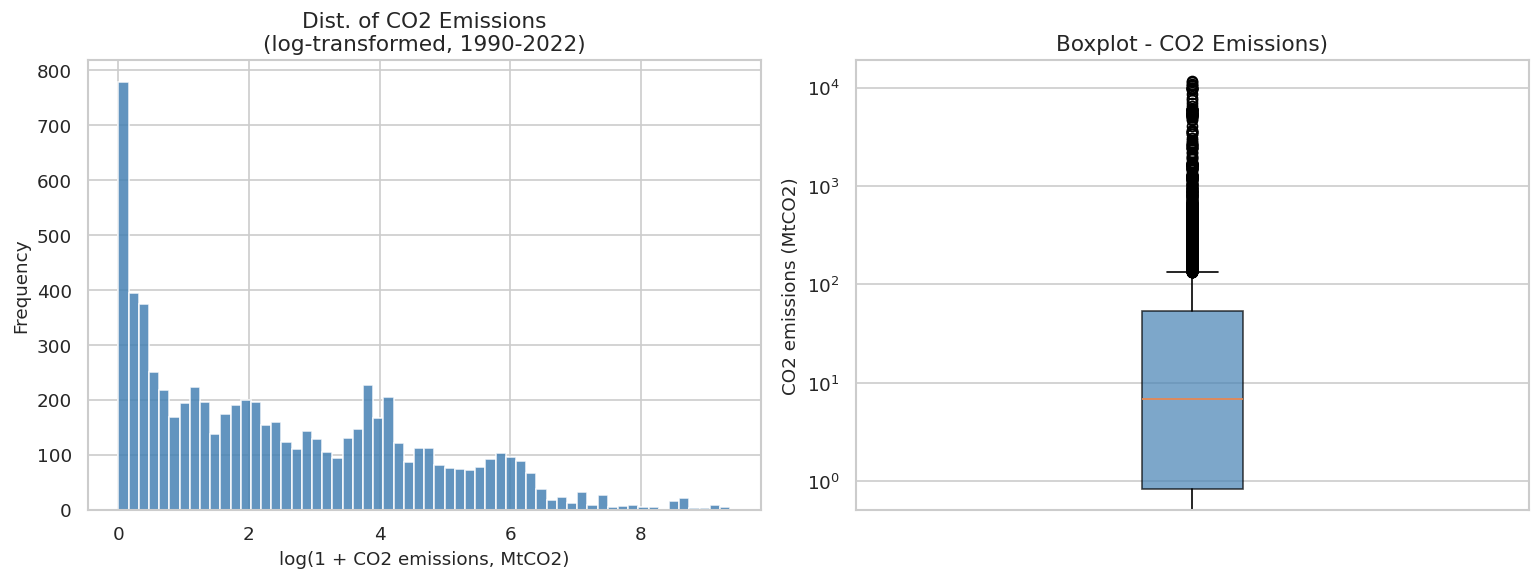

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram (log scale for readability)
axes[0].hist(np.log1p(co2_em), bins=60, color='steelblue', edgecolor='white', alpha=0.85) #use log1p to avoid undef. with small values
axes[0].set_xlabel('log(1 + CO2 emissions, MtCO2)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Dist. of CO2 Emissions\n(log-transformed, 1990-2022)')

# Box plot
axes[1].boxplot(co2_em, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_yscale('log')
axes[1].set_ylabel('CO2 emissions (MtCO2)')
axes[1].set_title('Boxplot - CO2 Emissions)')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()


**Interpretation:**  
The raw distribution of CO2 emissions is extremely right-skewed, with the mean far exceeding the median. This reflects a handful of large economies — China, the United States, India, Russia — that dwarf the emissions of most countries. The standard deviation is extremely large, meaning that CO2 varies a lot across countries, with large economies dominating the emission. 

### 5b. Categorical Variable — World Region

**Research question:** *How are total CO2 emissions distributed across world regions, and which regions contribute most to global emissions over 1990–2022?*

**Why this variable is appropriate:**  
we will associate country iso codes with continents. Comparing emissions by continent reveals patterns in energy use associated with economic development of regions, history, policy, etc.


In [15]:
# The df_countries dataset doesn't have a continent column.  But I pulled that info from a table 
# already availabe in OWID: https://ourworldindata.org/grapher/continents-according-to-our-world-in-data.csv
# I downloaded it into the project folder.  Then I merge the continent info with df_countries dataframe.

continent_df = pd.read_csv("continents-OWID.csv")[['Code','World region according to OWID']].rename(
    columns={'Code':'iso_code','World region according to OWID':'continent'})

df_countries = df_countries.merge(continent_df, on='iso_code', how='left')

print("Continent distribution (rows):")
print(df_countries['continent'].value_counts())

Continent distribution (rows):
continent
Africa           1815
Asia             1683
Europe           1518
North America    1122
Oceania           627
South America     396
Name: count, dtype: int64


In [ ]:
# Total CO2 per region across all years (sum)
region_co2 = (df_countries.dropna(subset=['co2','continent'])   # drop lines with NaN in co2 or continent
    .groupby('continent')['co2'].sum().sort_values(ascending=False))

region_pct = (region_co2 / region_co2.sum() * 100).round(1)
summary_table = pd.DataFrame({'Total CO2 (MtCO2)': region_co2.round(0),'Share (%)': region_pct})
print(summary_table)

               Total CO2 (MtCO2)  Share (%)
continent                                  
Asia                    455662.0       47.5
North America           219313.0       22.9
Europe                  203632.0       21.2
Africa                   35884.0        3.7
South America            30254.0        3.2
Oceania                  13537.0        1.4


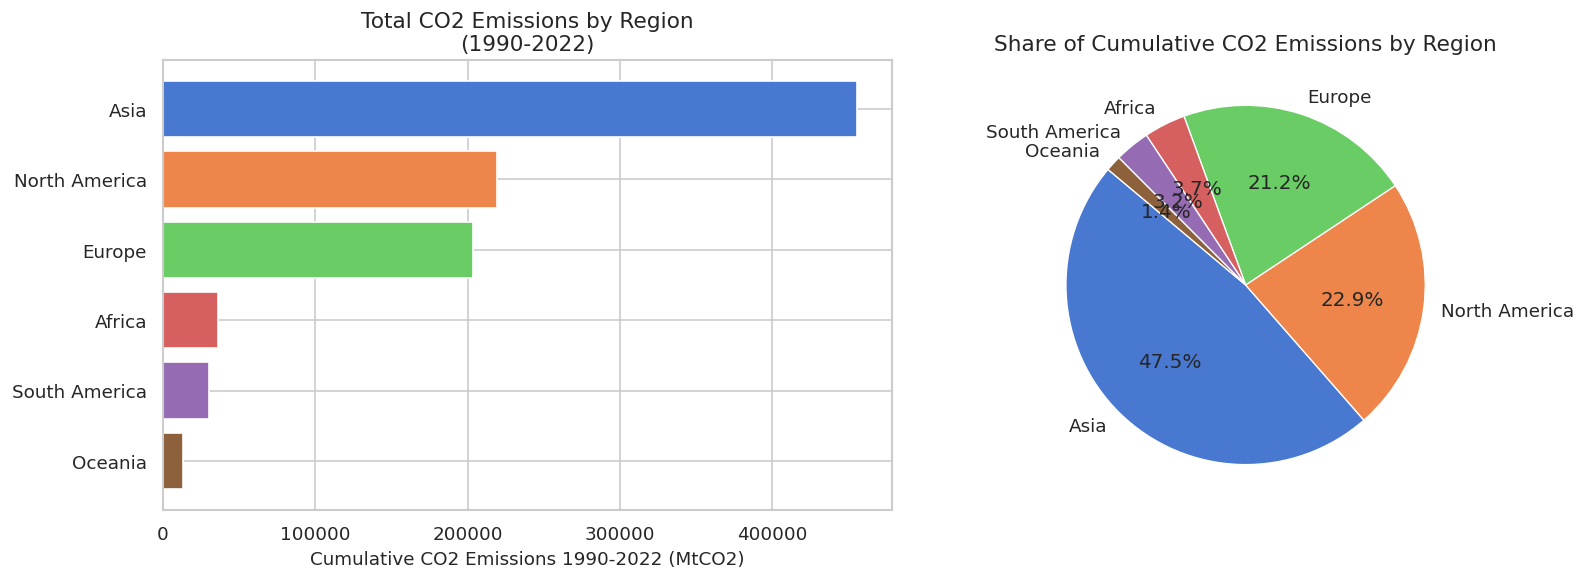

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = sns.color_palette('muted', n_colors=len(region_co2))
axes[0].barh(region_co2.index[::-1], region_co2.values[::-1], color=colors[::-1])
axes[0].set_xlabel('Cumulative CO2 Emissions 1990-2022 (MtCO2)')
axes[0].set_title('Total CO2 Emissions by Region\n(1990-2022)')

# Pie chart
axes[1].pie(region_co2.values, labels=region_co2.index,
            autopct='%1.1f%%', colors=colors, startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=0.8))
axes[1].set_title('Share of Cumulative CO2 Emissions by Region')

plt.tight_layout()
plt.show()

**Interpretation:**  
Asia dominates global cumulative emissions from 1990–2022, accounting for the largest share, driven primarily by China's rapid industrialization. Europe and North America follow, reflecting their long histories of fossil fuel use. Africa and Oceania contribute comparatively little despite representing a large portion of the world's land area. This disparity underscores a key climate justice concern: the regions historically most responsible for emissions are not the same as those most vulnerable to climate impacts.


### 5c. Relationship Between Variables — Patents vs. CO₂ Emissions

**Research question:** *Is there a relationship between a country's technological innovation (resident patent filings per million people) and its annual CO₂ emissions per capita? Does higher innovation correlate with lower or higher emissions intensity?*

**Why we expect an association:**  
Countries with more patent activity tend to have higher GDP and more industrialized economies — which could correlate with either higher emissions (more production) or lower emissions (cleaner technology). The direction of the relationship is interesting and not obvious in advance.


In [ ]:
# Use most recent 5-year average per country to capture current reality, as GDP has grown dramatically over the last 30 years
recent = df_countries[df_countries['year'] >= 2015].copy()
recent = recent.dropna(subset=['patent_per_million','co2_per_capita','gdp_per_capita','continent']) # drop lines with NAs in 4 vars

# Average across years per country
recent_df = (
    recent.groupby(['country','iso_code','continent'])
    [['patent_per_million','co2_per_capita','gdp_per_capita']].mean().reset_index().dropna())

print(f"Countries in this analysis: {len(recent_df)}")
recent_df[['patent_per_million','co2_per_capita','gdp_per_capita']].describe().round(2)

Countries in this analysis: 116


,patent_per_million,co2_per_capita,gdp_per_capita
count,116.00,116.00,116.00
mean,78.78,5.56,22233.34
std,221.03,6.25,20656.51
min,0.02,0.05,685.77
25%,2.50,1.62,8129.50
50%,14.35,3.94,15232.27
75%,49.66,7.25,31519.44
max,1947.69,36.73,134206.56


In [20]:
# Pearson correlation on log-transformed values
log_pat = np.log1p(recent_df['patent_per_million'])
log_co2 = np.log1p(recent_df['co2_per_capita'])
r = np.corrcoef(log_pat, log_co2)[0, 1]
print(f"Pearson r (log-log): {r:.3f}")

Pearson r (log-log): 0.648


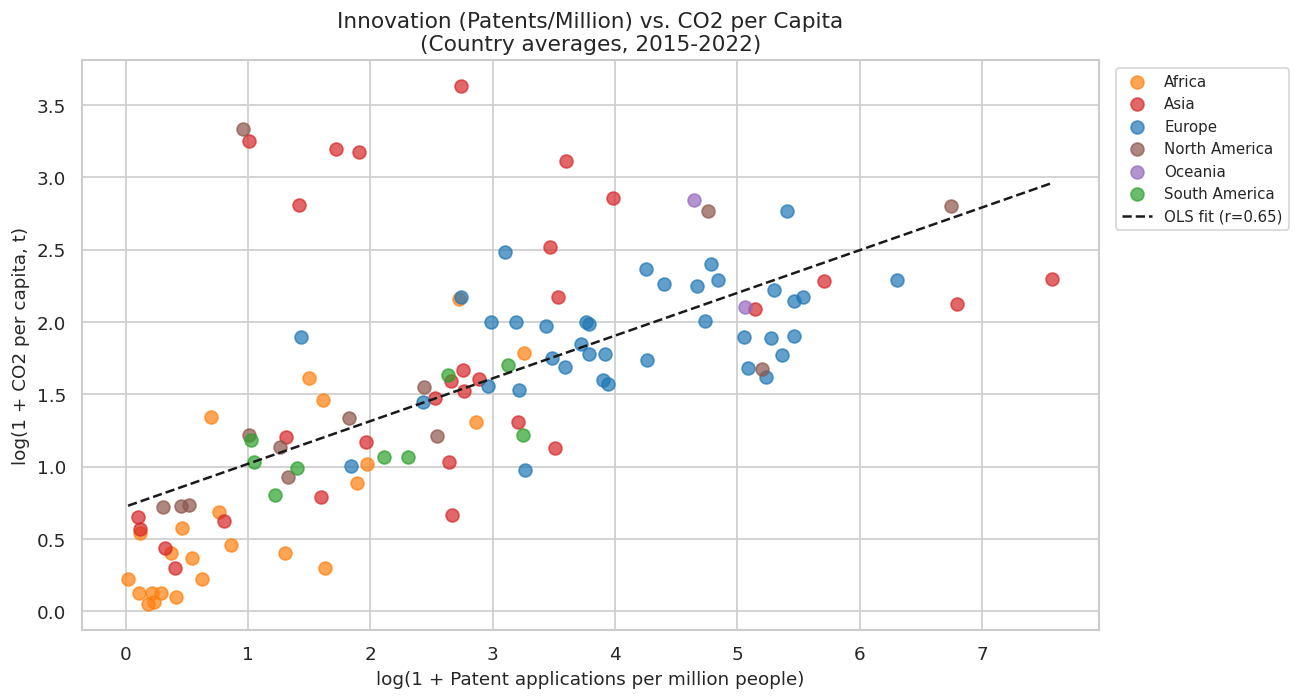

In [21]:
fig, ax = plt.subplots(figsize=(11, 6))

continents = recent_df['continent'].unique()
palette = dict(zip(continents, sns.color_palette('tab10', n_colors=len(continents))))

for cont, grp in recent_df.groupby('continent'):
    ax.scatter(np.log1p(grp['patent_per_million']), np.log1p(grp['co2_per_capita']),
        label=cont, alpha=0.7, s=60, color=palette[cont])

# Regression line
x_all = np.log1p(recent_df['patent_per_million'])
y_all = np.log1p(recent_df['co2_per_capita'])
m, b = np.polyfit(x_all, y_all, 1)
xr = np.linspace(x_all.min(), x_all.max(), 200)
ax.plot(xr, m * xr + b, 'k--', linewidth=1.5, label=f'OLS fit (r={r:.2f})')

ax.set_xlabel('log(1 + Patent applications per million people)')
ax.set_ylabel('log(1 + CO2 per capita, t)')
ax.set_title('Innovation (Patents/Million) vs. CO2 per Capita\n(Country averages, 2015-2022)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('fig_patents_vs_co2.png', bbox_inches='tight')
plt.show()

**Interpretation:**  
The log-log scatter plot reveals a **positive association** between patent intensity and CO2 per capita across countries. Nations with high patent activity — Japan, South Korea, the United States, Germany — also tend to have high per-capita emissions. This suggests that, at the cross-country level, patent activity is a marker of industrial development and energy intensity rather than a signal of clean-technology adoption. The relationship is moderate (r around .65) and varies by region: European countries show relatively high patents with moderate emissions, suggesting cleaner energy mixes.


### 5d. Nonparametric Inference — Bootstrap Confidence Interval for the Median CO2 per Capita

**Research question:** *What is the median CO2 per capita among all country-years from 1990–2022, and how precisely can we estimate it from a 10% random sample?*

**Procedure:** We draw a random sample of approximately 10% of country-year observations, then use **bootstrap resampling** (10,000 iterations) to construct a 95% confidence interval for the median. This nonparametric approach is appropriate because the distribution is heavily skewed and we make no distribution assumptions.


In [22]:
# Full population of non-NaN co2_per_capita observations
population_ = df_countries['co2_per_capita'].dropna().values
N = len(population_)
print(f"Full population size N = {N:,}")
print(f"Population median = {np.median(population_):.4f} t CO2/person")

# 10% random sample
np.random.seed(42)
n_sample = int(round(N * 0.10))
sample = np.random.choice(population_, size=n_sample, replace=False)
print(f"\nSample size n = {n_sample} ({n_sample/N*100:.1f}%)")
print(f"Sample median  = {np.median(sample):.4f} t CO2/person")

Full population size N = 7,016
Population median = 2.7137 t CO2/person

Sample size n = 702 (10.0%)
Sample median  = 2.6660 t CO2/person


In [23]:
# Bootstrap: resample with replacement from the sample
B = 10_000
boot_median = np.array([
    np.median(np.random.choice(sample, size=n_sample, replace=True))
    for _ in range(B)
])

ci_low, ci_high = np.percentile(boot_median, [2.5, 97.5])
se = boot_median.std()

print(f"Bootstrap SE of median     : {se:.4f}")
print(f"95% CI (percentile method) : [{ci_low:.4f}, {ci_high:.4f}] t CO2/person")
print(f"Interval width             : {ci_high - ci_low:.4f}")

Bootstrap SE of median     : 0.2150
95% CI (percentile method) : [2.2681, 3.1432] t CO2/person
Interval width             : 0.8751


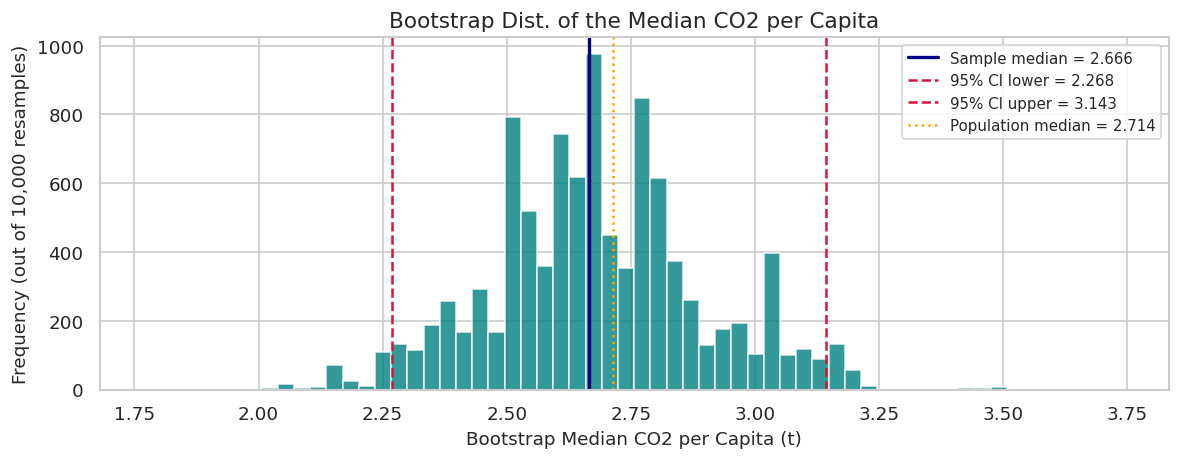

In [24]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(boot_median, bins=60, color='teal', edgecolor='white', alpha=0.8)
ax.axvline(np.median(sample), color='navy', linewidth=2,   label=f'Sample median = {np.median(sample):.3f}')
ax.axvline(ci_low,  color='crimson', linewidth=1.5, linestyle='--', label=f'95% CI lower = {ci_low:.3f}')
ax.axvline(ci_high, color='crimson', linewidth=1.5, linestyle='--', label=f'95% CI upper = {ci_high:.3f}')
ax.axvline(np.median(population_), color='orange', linewidth=1.5,
    linestyle=':', label=f'Population median = {np.median(population_):.3f}')
ax.set_xlabel('Bootstrap Median CO2 per Capita (t)')
ax.set_ylabel('Frequency (out of 10,000 resamples)')
ax.set_title('Bootstrap Dist. of the Median CO2 per Capita')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_bootstrap_median.png', bbox_inches='tight')
plt.show()

**Interpretation:**  
The 10% random sample yields a sample median very close to the true population median, demonstrating that even a small random sample provides a reliable estimate of the central tendency. The bootstrap 95% confidence interval is narrow relative to the overall spread of the data, indicating that the median is estimated with good precision. The bootstrap distribution is approximately symmetric and bell-shaped around the sample median. The population median falls within the 95% CI, validating the method.


## 6. Conclusions and Recommendations

### What We Found

**Quantitative analysis (CO2 emissions):**  
Annual CO₂ emissions are extremely right-skewed — a small number of large economies generate the vast majority of emissions. 

**Categorical analysis (World Region):**  
Asia accounts for the largest share of cumulative CO2 emissions from 1990–2022, followed by Europe and North America. Africa contributes the least, despite being home to over 1.4 billion people — illustrating profound inequity in the historical emissions record.

**Exploratory relationship (Patents vs. CO2 per capita):**  
Higher patent activity per capita correlates positively with higher CO2 per capita at the cross-country level, suggesting that innovation proxied by patent applications reflects industrial development rather than decarbonization. European countries partially deviate from this trend, showing relatively high patent rates with moderate emissions, hinting at the effect of clean energy policies.

**Nonparametric inference (Bootstrap CI for median CO2 per capita):**  
A 10% random sample provides a reliable estimate of the population median CO2 per capita. The 95% bootstrap confidence interval is narrow and encloses the true population median, demonstrating the validity of the bootstrap approach for skewed, non-normal data.


### For next project(s)

1. **"Green" patent filtering:** Separate clean-energy or environmental patents to test whether innovation specifically correlates with lower emissions intensity.
2. **Standard of living:** Identify indicators other than GDP/capita to test the causal relations between decarbonization and human development.
5. **Forecast:** Build time-series forecasts to predict emissions trajectories under different renewable adoption scenarios.
